In [18]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [19]:
df = pd.read_csv('fear_greed_index.csv')

In [20]:
df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [21]:
df.shape

(2644, 4)

In [22]:
df.describe()

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


In [23]:
df.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [24]:
df['date'] = pd.to_datetime(df['date'])

In [25]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek

In [26]:
print(df['date'].dtype)

datetime64[us]


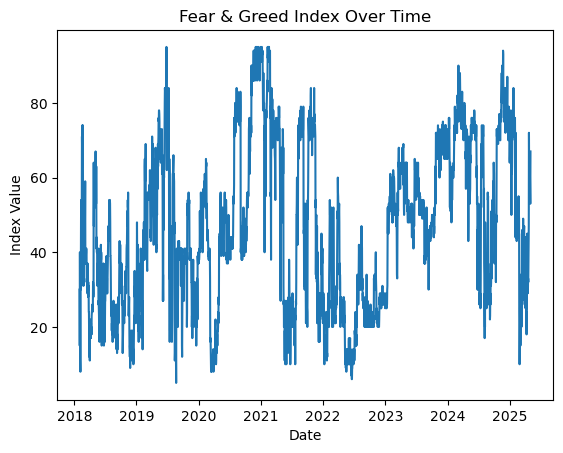

In [27]:
plt.plot(df['date'], df['value'])
plt.title("Fear & Greed Index Over Time")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.show()

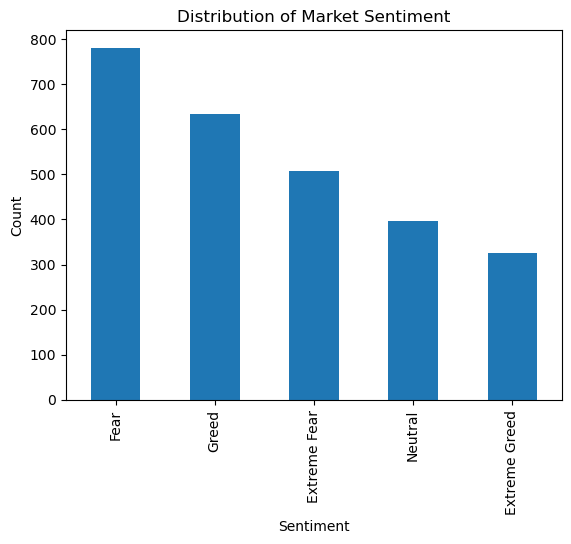

In [35]:
df['classification'].value_counts().plot(kind='bar')
plt.title("Distribution of Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

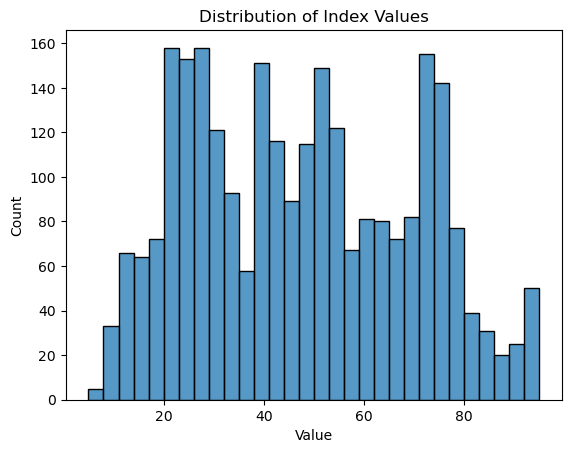

In [36]:
sns.histplot(df['value'], bins=30)
plt.title("Distribution of Index Values")
plt.xlabel("Value")
plt.show()

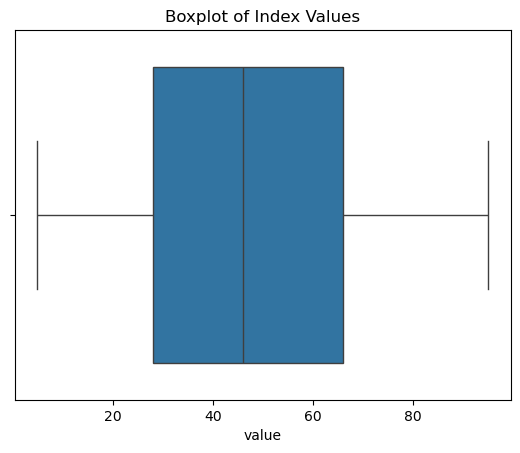

In [37]:
sns.boxplot(x=df['value'])
plt.title("Boxplot of Index Values")
plt.show()

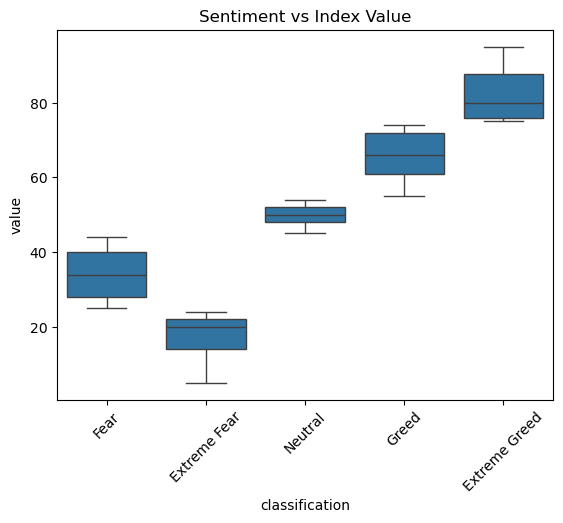

In [38]:
sns.boxplot(x='classification', y='value', data=df)
plt.title("Sentiment vs Index Value")
plt.xticks(rotation=45)
plt.show()

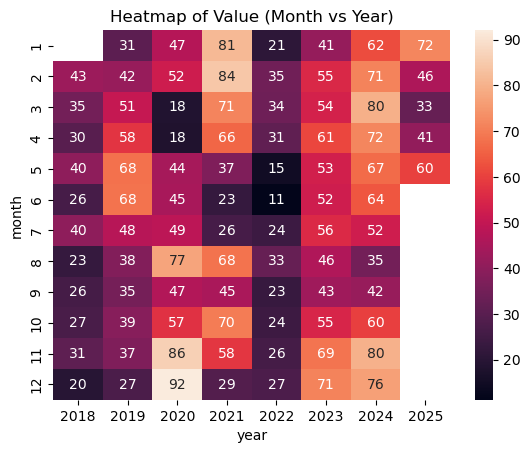

In [39]:
pivot = df.pivot_table(values='value', index='month', columns='year')

sns.heatmap(pivot, annot=True)
plt.title("Heatmap of Value (Month vs Year)")
plt.show()

In [28]:
X = df[['value', 'year', 'month', 'day', 'dayofweek']]
y = df['classification']

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)


num_col = ['value', 'year', 'month', 'day', 'dayofweek']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_col)
    ]
)

In [30]:
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(n_estimators=200, random_state=42))
])

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['value', 'year', 'month',
                                                   'day', 'dayofweek'])])),
                ('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [33]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       111
           1       1.00      1.00      1.00        67
           2       1.00      1.00      1.00       144
           3       1.00      1.00      1.00       131
           4       1.00      1.00      1.00        76

    accuracy                           1.00       529
   macro avg       1.00      1.00      1.00       529
weighted avg       1.00      1.00      1.00       529



In [34]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(pipeline, X, y, cv=5)

print("CV Accuracy:", scores.mean())

CV Accuracy: 0.9946969696969697
